# Classical Machine Learning - Brain Tumor Classification
### Approach: Feature Extraction (Scikit-Image) + Traditional Classifiers (Scikit-Learn)

**Objective:**
Before attempting Deep Learning, it is standard data science practice to establish a "Baseline" using classical Machine Learning. 
In this pipeline, we will manually extract mathematical features from MRI scans (like texture, edges, and contrast) and feed them into traditional algorithms (Random Forest and K-Nearest Neighbors) to see how accurately they can detect tumors without a neural network.

---
## 1. Environment Setup & Library Imports
Importing necessary libraries for mathematical image processing, dimensionality reduction (PCA), and classical modeling.

In [2]:
# Standard library for OS pathing, file handling, and performance tracking
import os
import glob
import time

# Data manipulation and numerical computing matrices
import numpy as np

# Visualization libraries for plotting stats and images
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats

# Advanced Mathematical Transforms
import pywt  # PyWavelets for frequency/texture analysis

# Classical Image Processing (Scikit-Image)
# Used to manually extract edges, textures, and histograms from medical scans
from skimage import (
    io,
    color,
    filters,
    exposure,
    morphology,
    feature
)
from skimage.transform import resize
from skimage import filters as skfilters

# Machine Learning: Preprocessing & Dimensionality Reduction
# Essential for shrinking massive image datasets into manageable data points
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

# Machine Learning: Traditional Classifier Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

# Machine Learning: Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

---
## 2. Data Ingestion & Exploratory Data Analysis (EDA)
In Classical Machine Learning, understanding the raw state of your data is paramount. 
Unlike Neural Networks which standardize inputs automatically, traditional algorithms require us to know exactly what we are feeding them. 

This module performs three critical tasks:
1. **Dynamic Ingestion:** Scans the `data` directory, automatically detects classes (Normal/Tumor), and loads all raw images into memory.
2. **Visual Verification:** Plots a balanced random matrix of samples to ensure the data loaded correctly and isn't corrupted.
3. **Property Analysis:** Scans the entire dataset to calculate mathematical properties like resolution shapes and color-channel distributions (Grayscale vs. RGB). This tells us exactly how we need to pre-process the images in the next steps.


Found 2 classes: ['Normal', 'Tumor']
Found 3799 images in class 'Normal'
Found 3200 images in class 'Tumor'

Successfully loaded 6999 images in total
Class distribution: {'Normal': 3799, 'Tumor': 3200}


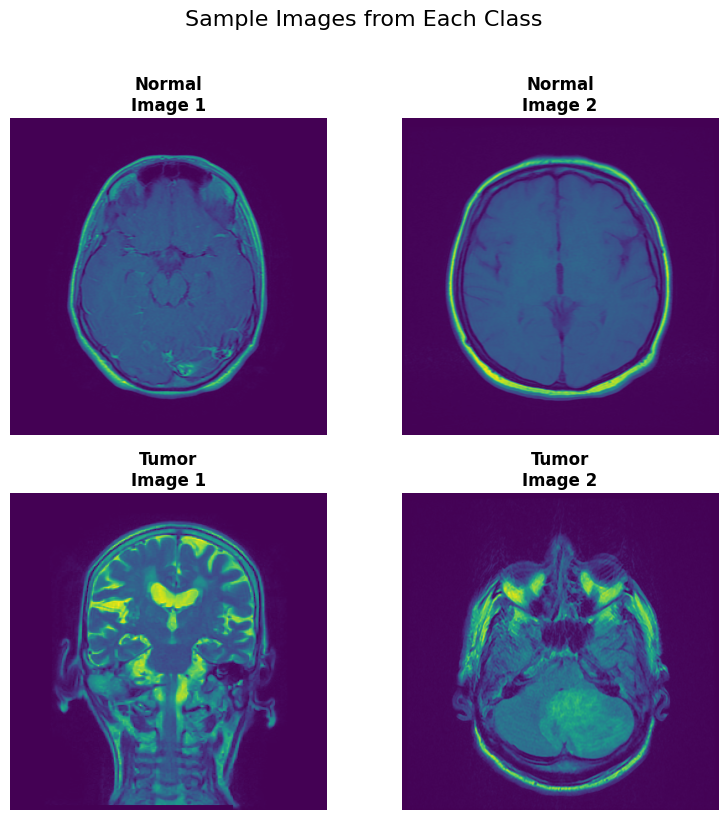


EDA: IMAGE MATHEMATICAL PROPERTIES
Number of unique image shapes/resolutions detected: 482
  Shape (351, 317, 3): 1 images (0.0%)
  Shape (254, 255, 3): 1 images (0.0%)
  Shape (267, 253, 3): 1 images (0.0%)
  Shape (335, 296, 3): 1 images (0.0%)
  Shape (398, 353, 3): 1 images (0.0%)

Color distribution:
  Color images: 508
  Grayscale images: 6491
  Other: 0


In [ ]:
# ==========================================
# DATA LOADING & EXPLORATION MODULE
# ==========================================

# Configuration Globals
DATA_FOLDER = "data"
IMAGE_EXTENSIONS = ["*.jpg", "*.jpeg", "*.png"]
SAMPLES_PER_CLASS = 2

def load_dataset(data_folder):
    """
    Dynamically scans the dataset directory, identifies classes based on folders, 
    and loads raw image matrices into memory.

    Parameters:
    -----------
    data_folder : str
        Relative or absolute path to the main data directory containing class subfolders.

    Returns:
    --------
    tuple: (images, labels, image_paths, class_folders)
        - images (list): Raw NumPy arrays representing the loaded images.
        - labels (list): Integer indices corresponding to the image's class.
        - image_paths (list): System paths for each image (useful for auditing/debugging).
        - class_folders (list): Extracted string names of the classes (e.g., ['Normal', 'Tumor']).
    """

    # 1. Discover classes dynamically by reading subdirectory names
    class_folders = [f for f in os.listdir(data_folder)
                    if os.path.isdir(os.path.join(data_folder, f))]
    class_folders.sort() # Alphabetical sorting ensures Class 0 is always 'Normal' and Class 1 is 'Tumor'

    print(f"Found {len(class_folders)} classes: {class_folders}")

    # Initialize memory storage
    images = []
    labels = []
    image_paths = []

    # 2. Iterate through each class and load images
    for class_idx, class_folder in enumerate(class_folders):
        folder_path = os.path.join(data_folder, class_folder)

        # Aggregate all matching image files using glob filtering
        class_image_paths = []
        for ext in IMAGE_EXTENSIONS:
            class_image_paths.extend(glob.glob(os.path.join(folder_path, ext)))

        print(f"Found {len(class_image_paths)} images in class '{class_folder}'")

        # 3. Read image matrices into memory via Scikit-Image
        for img_path in class_image_paths:
            try:
                img = io.imread(img_path)
                images.append(img)
                labels.append(class_idx)
                image_paths.append(img_path)
            except Exception as e:
                # Catch corrupted or unreadable images without crashing the entire loop
                print(f"Error loading {img_path}: {e}")

    print(f"\nSuccessfully loaded {len(images)} images in total")
    
    # Calculate and print the balance of the dataset
    class_counts = [labels.count(i) for i in range(len(class_folders))]
    print(f"Class distribution: {dict(zip(class_folders, class_counts))}")
    
    return images, labels, image_paths, class_folders


def show_balanced_samples(images, labels, class_folders, samples_per_class=2):
    """
    Plots a grid of randomly selected images from each class to visually verify data integrity.
    
    Parameters:
    -----------
    images : list
        List of raw image arrays.
    labels : list
        List of class indices corresponding to the images.
    class_folders : list
        List of class string names to be used as plot titles.
    samples_per_class : int, optional
        Number of random images to display per class (Default is 2).
    """

    # Initialize Matplotlib Figure Grid
    fig, axes = plt.subplots(len(class_folders), samples_per_class,
                            figsize=(samples_per_class * 4, len(class_folders) * 4))

    # Format axis array to mathematically handle edge cases (like a single class or 1 sample)
    if len(class_folders) == 1:
        axes = axes.reshape(1, -1)
    elif samples_per_class == 1:
        axes = axes.reshape(-1, 1)

    # Select and display samples
    for class_idx, class_name in enumerate(class_folders):
        # Extract indices of all images belonging to the current class
        class_indices = [i for i, label in enumerate(labels) if label == class_idx]

        # Randomly choose indices without replacement to avoid showing the same image twice
        sample_indices = np.random.choice(class_indices,
                                        size=min(samples_per_class, len(class_indices)),
                                        replace=False)

        # Plot onto the Matplotlib grid
        for i, idx in enumerate(sample_indices):
            ax = axes[class_idx, i]
            ax.imshow(images[idx])
            ax.set_title(f"{class_name}\nImage {i+1}", fontsize=12, weight='bold')
            ax.axis('off') # Hide axes for cleaner visual

    plt.suptitle("Sample Images from Each Class", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()


def display_image_properties(images, labels, class_folders):
    """
    Analyzes the entire loaded dataset to determine mathematical variances, 
    such as differing resolutions and color channel distributions.
    
    Parameters:
    -----------
    images : list
        List of raw image arrays.
    labels : list
        List of class indices.
    class_folders : list
        List of class string names.
    """

    print("\n==========================================")
    print("EDA: IMAGE MATHEMATICAL PROPERTIES")
    print("==========================================")

    # 1. Analyze Dimensions (Resolution)
    shapes = [img.shape for img in images]
    unique_shapes = list(set(shapes))

    print(f"Number of unique image shapes/resolutions detected: {len(unique_shapes)}")
    for shape in unique_shapes[:5]:  # Show top 5 shape occurrences 
        count = shapes.count(shape)
        print(f"  Shape {shape}: {count} images ({count/len(images)*100:.1f}%)")

    # 2. Analyze Color Channels
    # Shape lengths: 2 means (Height, Width) Grayscale. 3 means (Height, Width, Channels) RGB/RGBA
    color_images = sum(1 for img in images if len(img.shape) == 3 and img.shape[2] == 3)
    grayscale_images = sum(1 for img in images if len(img.shape) == 2 or
                          (len(img.shape) == 3 and img.shape[2] == 1))

    print(f"\nColor distribution:")
    print(f"  Color images: {color_images}")
    print(f"  Grayscale images: {grayscale_images}")
    print(f"  Other: {len(images) - color_images - grayscale_images}")


# ==========================================
# MAIN EXECUTION BLOCK (EDA)
# ==========================================
if __name__ == "__main__":
    # 1. Ingest Data
    images, labels, image_paths, class_folders = load_dataset(DATA_FOLDER)

    # 2. Visually Verify
    show_balanced_samples(images, labels, class_folders, samples_per_class=SAMPLES_PER_CLASS)

    # 3. Analyze Mathematical Variances
    display_image_properties(images, labels, class_folders)

---
## 3. Mathematical Image Preprocessing
Raw medical images are notoriously difficult for traditional Machine Learning algorithms to interpret directly due to varying resolutions, equipment noise, and poor contrast.

To prepare the MRI scans for feature extraction, we process every single image through a strict 7-Step pipeline:
1. **Resizing:** Forcing a uniform `224x224` resolution.
2. **Grayscaling:** Flattening 3-channel RGB images to a single 2D mathematical matrix.
3. **Median Filtering:** Removing "Salt and Pepper" artifact noise without blurring edges.
4. **Gaussian Smoothing:** Blurring out general background static.
5. **CLAHE (Contrast Limited Adaptive Histogram Equalization):** Dynamically popping the contrast of dense areas (making the tumor boundaries highly visible).
6. **Unsharp Masking:** Sharpening the boundaries that CLAHE revealed.
7. **Min-Max Normalization:** Scaling all pixel values mathematically to be exactly between `0.0` and `1.0`.


Starting preprocessing of 6999 images...
Progress: 0/6999 images (0.0%)
Progress: 100/6999 images (1.4%)
Progress: 200/6999 images (2.9%)
Progress: 300/6999 images (4.3%)
Progress: 400/6999 images (5.7%)
Progress: 500/6999 images (7.1%)
Progress: 600/6999 images (8.6%)
Progress: 700/6999 images (10.0%)
Progress: 800/6999 images (11.4%)
Progress: 900/6999 images (12.9%)
Progress: 1000/6999 images (14.3%)
Progress: 1100/6999 images (15.7%)
Progress: 1200/6999 images (17.1%)
Progress: 1300/6999 images (18.6%)
Progress: 1400/6999 images (20.0%)
Progress: 1500/6999 images (21.4%)
Progress: 1600/6999 images (22.9%)
Progress: 1700/6999 images (24.3%)
Progress: 1800/6999 images (25.7%)
Progress: 1900/6999 images (27.1%)
Progress: 2000/6999 images (28.6%)
Progress: 2100/6999 images (30.0%)
Progress: 2200/6999 images (31.4%)
Progress: 2300/6999 images (32.9%)
Progress: 2400/6999 images (34.3%)
Progress: 2500/6999 images (35.7%)
Progress: 2600/6999 images (37.1%)
Progress: 2700/6999 images (38.6%

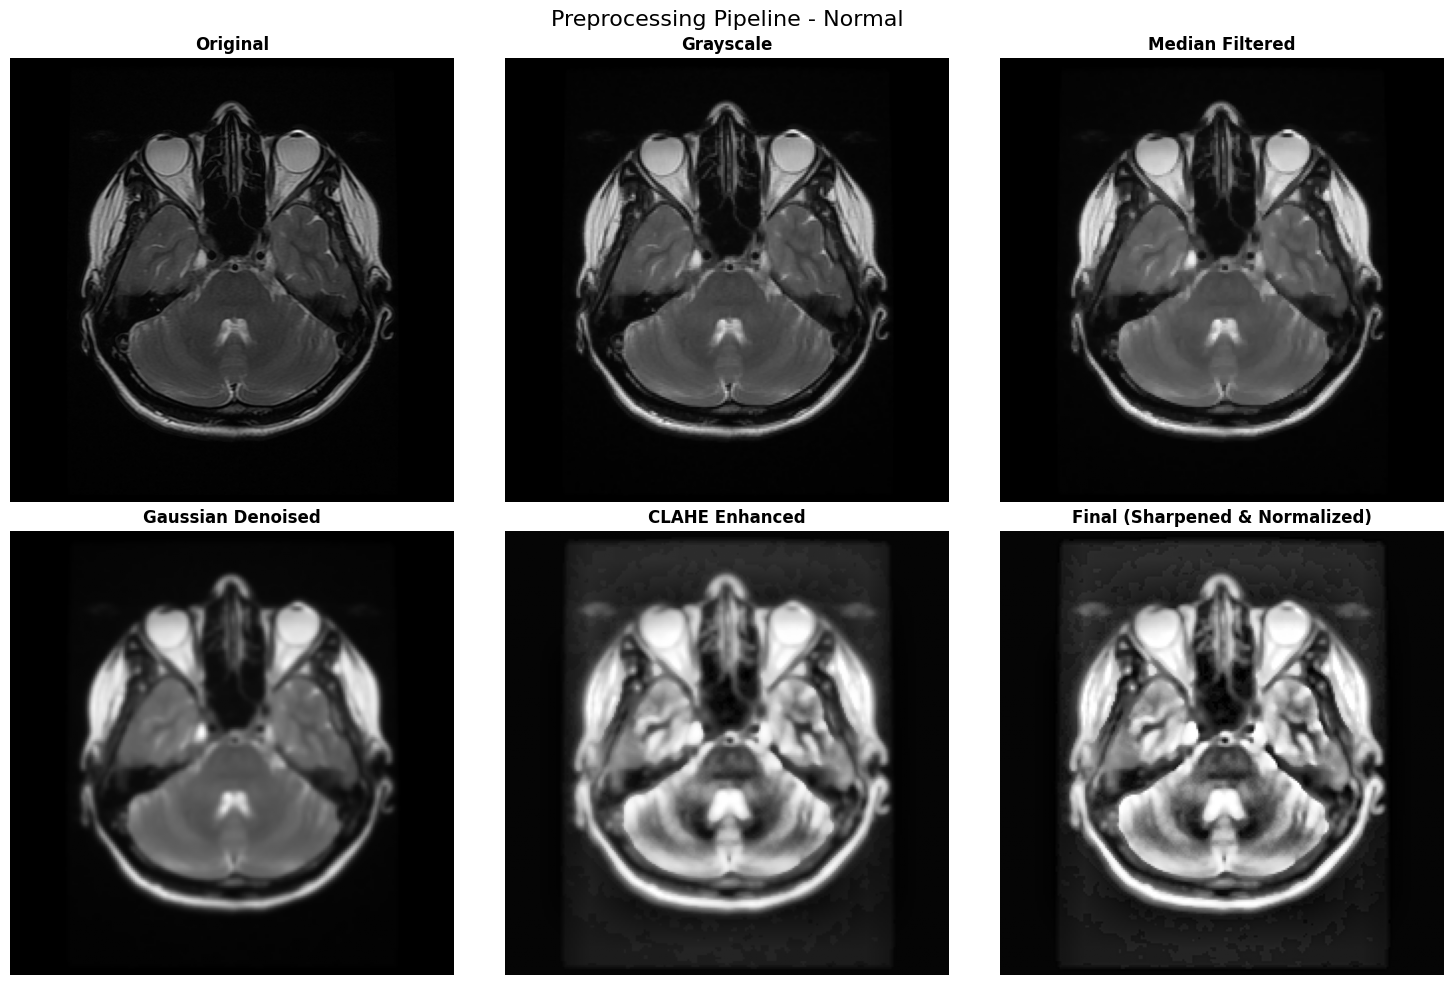

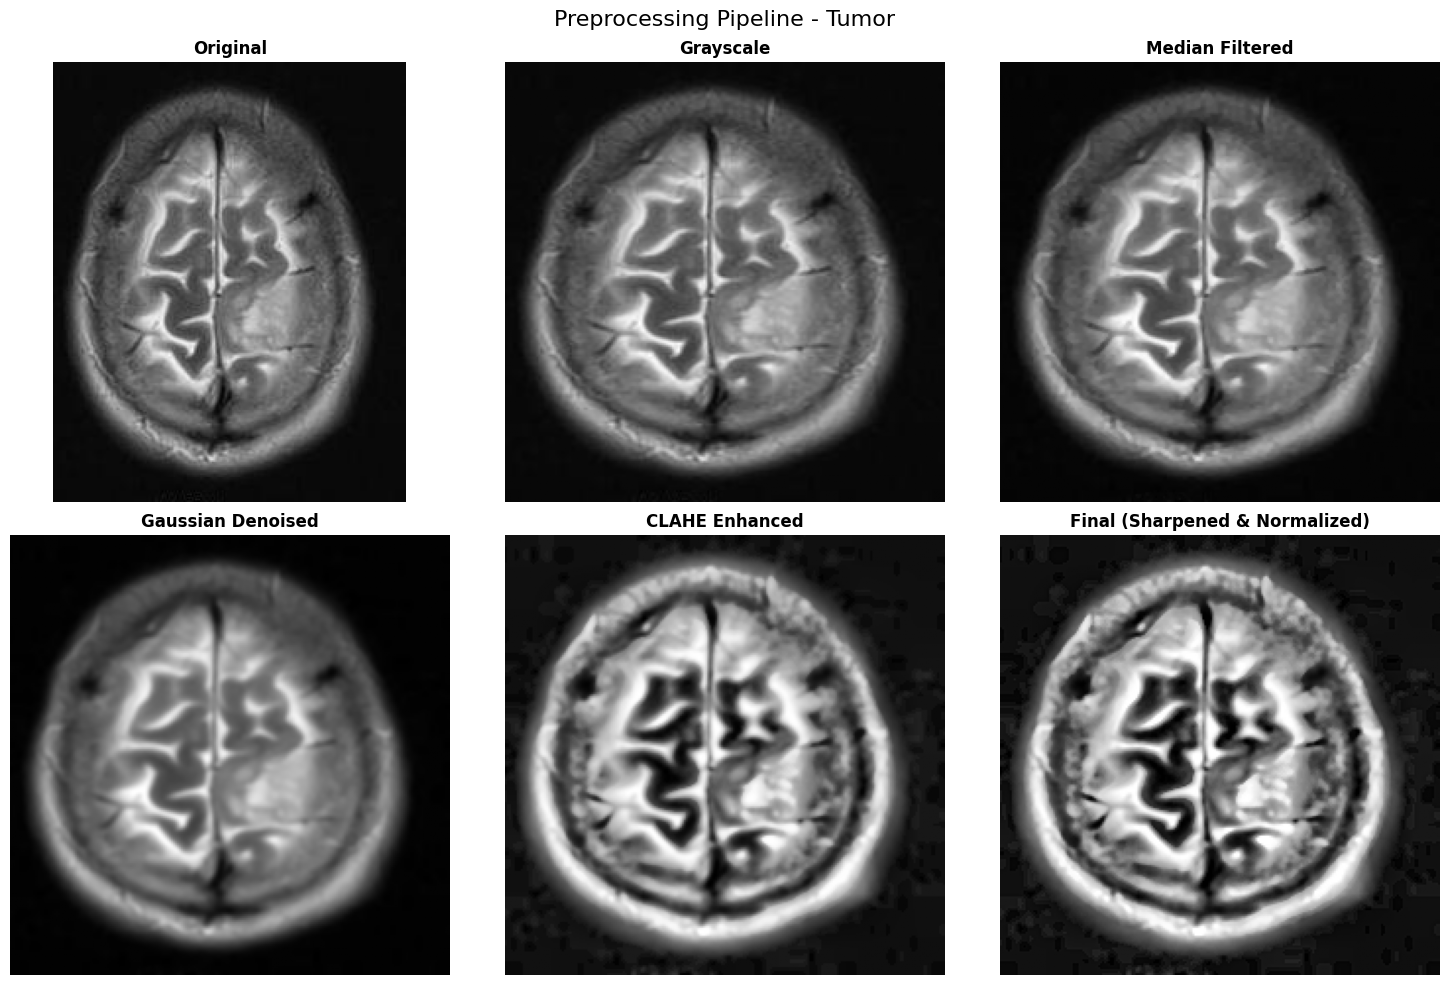

In [4]:
def preprocess_image(img, target_size=(224, 224)):
    """
    Applies a comprehensive mathematical preprocessing pipeline to medical images.
    Specifically designed for MRI scans to reduce equipment noise and pop tumor contrast.
    
    Parameters:
    -----------
    img : numpy.ndarray
        Raw input image matrix (can be grayscale or RGB).
    target_size : tuple, optional
        Target dimensions for uniform resizing (Default is (224, 224)).
    
    Returns:
    --------
    tuple : (gray, median_filtered, denoised, enhanced, sharpened, normalized)
        Returns the mathematical state of the image at every stage of the pipeline 
        (useful for visual auditing and step-by-step debugging).
        The final 'normalized' array is what gets fed to the ML model.
    """
    # Step 1: Resize image to consistent dimensions
    resized_img = resize(img, target_size, anti_aliasing=True)

    # Step 2: Convert to 2D Grayscale if the image is colored (RGB)
    if len(resized_img.shape) == 3 and resized_img.shape[2] > 1:
        gray = color.rgb2gray(resized_img)
    else:
        gray = resized_img.copy()

    # Step 3: Remove sharp, artifact noise (Salt & Pepper)
    # Disk radius of 1 provides gentle noise removal while strictly preserving edges
    median_filtered = filters.median(gray, footprint=morphology.disk(1))

    # Step 4: Apply Gaussian smoothing for general background static reduction
    # Sigma=1 provides moderate smoothing without excessive blurring
    denoised = filters.gaussian(median_filtered, sigma=1)

    # Step 5: Enhance local contrast using CLAHE (Contrast Limited Adaptive Histogram Equalization)
    # clip_limit=0.03 prevents the mathematical over-amplification of noise in uniform regions
    enhanced = exposure.equalize_adapthist(denoised, clip_limit=0.03)

    # Step 6: Apply unsharp masking for edge enhancement
    # This specifically helps highlight the hard boundaries of tumors
    sharpened = filters.unsharp_mask(enhanced, radius=1, amount=1)

    # Step 7: Min-Max Normalization 
    # Squashes all physical pixel values mathematically into a [0.0, 1.0] range
    # Essential for mathematical stability when feeding traditional ML models
    normalized = (sharpened - sharpened.min()) / (sharpened.max() - sharpened.min())

    return gray, median_filtered, denoised, enhanced, sharpened, normalized


def preprocess_dataset(images, verbose=True, progress_interval=10):
    """
    Feeds the entire raw dataset array through the preprocessing pipeline.
    
    Parameters:
    -----------
    images : list
        List of raw input image arrays.
    verbose : bool, optional
        If True, prints console updates to track processing (Default: True).
    progress_interval : int, optional
        How many images to process before printing an update (Default: 10).
    
    Returns:
    --------
    list : A new list containing the final, normalized [0.0, 1.0] image matrices.
    """
    preprocessed_images = []
    total_images = len(images)

    if verbose:
        print(f"Starting preprocessing of {total_images} images...")
        print("=" * 50)

    for i, img in enumerate(images):
        if verbose and i % progress_interval == 0:
            progress_percent = (i / total_images) * 100
            print(f"Progress: {i}/{total_images} images ({progress_percent:.1f}%)")

        # Run the full 7-step pipeline on the image
        gray, median_filtered, denoised, enhanced, sharpened, normalized = preprocess_image(img)

        # Store only the final, mathematically clean 'normalized' version
        preprocessed_images.append(normalized)

    if verbose:
        print("=" * 50)
        print(f"✓ Preprocessing complete! Processed {total_images} images.")

    return preprocessed_images


def visualize_preprocessing_pipeline(img, class_name="Sample"):
    """
    Visualize all preprocessing steps for a single image.

    Parameters:
    -----------
    img : numpy.ndarray
        Input image to visualize
    class_name : str, optional
        Name of the class for the title
    """
    # Push image through pipeline and catch all intermediary states
    gray, median_filtered, denoised, enhanced, sharpened, normalized = preprocess_image(img)

    # Create visualization grid
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    # Define the visual stages to map onto the grid
    stages = [
        ("Original", img),
        ("Grayscale", gray),
        ("Median Filtered", median_filtered),
        ("Gaussian Denoised", denoised),
        ("CLAHE Enhanced", enhanced),
        ("Final (Sharpened & Normalized)", normalized)
    ]

    
    for idx, (title, image) in enumerate(stages):
        ax = axes[idx // 3, idx % 3]

        # Ensure Original RGB images render in color, but processing steps render in gray
        if len(image.shape) == 3 and image.shape[2] == 3:
            ax.imshow(image)
        else:
            ax.imshow(image, cmap='gray')

        ax.set_title(title, fontsize=12, weight='bold')
        ax.axis('off')

    plt.suptitle(f"Preprocessing Pipeline - {class_name}", fontsize=16)
    plt.tight_layout()
    plt.show()


# ==========================================
# MAIN EXECUTION BLOCK (PREPROCESSING)
# ==========================================
if __name__ == "__main__":
    # 1. Push all loaded images through the mathematical pipeline
    preprocessed_images = preprocess_dataset(images, verbose=True, progress_interval=100)

    # 2. Visually audit the pipeline using the first image from each class
    print("\nVisualizing preprocessing pipeline on sample images...")
    for class_idx, class_name in enumerate(class_folders[:2]):  
        # Grab the first image index that matches the current class
        sample_idx = next(i for i, label in enumerate(labels) if label == class_idx)
        visualize_preprocessing_pipeline(images[sample_idx], class_name)



---
## 4. Mathematical Feature Extraction (The Core of Classical ML)
Unlike Deep Learning, which learns features automatically inside its convolutional layers, Classical Machine Learning requires us to manually extract mathematical representations of our images to feed into the algorithms.
This massive function analyzes every single pixel of our normalized images, 
checking for:
- **HOG (Histogram of Oriented Gradients):** Captures physical shapes and contours.
- **LBP (Local Binary Pattern):** Analyzes micro-textures at different scales.
- **GLCM (Gray Level Co-occurrence Matrix):** Measures contrast, energy, and pixel correlation.
- **Gabor Filters & Wavelets (PyWavelets):** Breaks the image down into frequency domains.
- **Statistical & Gradient Magnitudes:** Measures edge strength (Sobel) and global intensity (Mean, Std, Skewness).

In [5]:
# ==========================================
# ADVANCED FEATURE EXTRACTION CONFIGURATION
# ==========================================
FEATURE_CONFIG = {
    'hog': {
        'orientations': 9,
        'pixels_per_cell': (8, 8),
        'cells_per_block': (2, 2)
    },
    'lbp': {
        'radius_1': 1,
        'points_1': 8,
        'radius_2': 2,
        'points_2': 16
    },
    'glcm': {
        'distances': [1, 2],
        'angles': [0, np.pi/4, np.pi/2, 3*np.pi/4],
        'properties': ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation']
    },
    'gabor': {
        'frequencies': [0.1, 0.2, 0.3],
        'orientations': [0, np.pi/4, np.pi/2, 3*np.pi/4]
    },
    'wavelet': {
        'wavelet': 'db4',
        'level': 2
    }
}


def extract_features(preprocessed_img):
    """
    Extracts a massive, comprehensive mathematical feature vector from a single processed image.
    These features represent the "knowledge" that traditional ML models will learn from.
    Parameters:
    -----------
    preprocessed_img : numpy.ndarray
        A 2D Grayscale image matrix, normalized between [0.0, 1.0].
    Returns:
    --------
    numpy.ndarray : A 1D flat vector containing mathematical features.
    """
    features = []

    # ===== 1. HOG (Histogram of Oriented Gradients) =====
    # Detects structure, shape, and edges (crucial for finding tumor boundaries)
    hog_features = feature.hog(
        preprocessed_img,
        orientations=FEATURE_CONFIG['hog']['orientations'],
        pixels_per_cell=FEATURE_CONFIG['hog']['pixels_per_cell'],
        cells_per_block=FEATURE_CONFIG['hog']['cells_per_block'],
        visualize=False
    )
    features.extend(hog_features)

    # ===== 2. Multi-Scale LBP (Local Binary Pattern) =====
    # Detects micro-textures (like the grainy tissue of a tumor vs normal brain matter)
    # Scale 1: Fine texture details (Radius=1
    lbp_r1 = feature.local_binary_pattern(
        preprocessed_img,
        P=FEATURE_CONFIG['lbp']['points_1'],
        R=FEATURE_CONFIG['lbp']['radius_1'],
        method='uniform'
    )
    lbp_hist_r1, _ = np.histogram(lbp_r1, bins=np.arange(0, 11), density=True)
    features.extend(lbp_hist_r1)

    # Scale 2: Coarser texture patterns (Radius=2)
    lbp_r2 = feature.local_binary_pattern(
        preprocessed_img,
        P=FEATURE_CONFIG['lbp']['points_2'],
        R=FEATURE_CONFIG['lbp']['radius_2'],
        method='uniform'
    )
    lbp_hist_r2, _ = np.histogram(lbp_r2, bins=np.arange(0, 19), density=True)
    features.extend(lbp_hist_r2)

    # ===== 3. GLCM (Gray Level Co-occurrence Matrix) =====
    # Measures how often pairs of pixel values occur next to each other (Contrast, Homogeneity)
    img_uint8 = (preprocessed_img * 255).astype(np.uint8)

    glcm = feature.graycomatrix(
        img_uint8,
        distances=FEATURE_CONFIG['glcm']['distances'],
        angles=FEATURE_CONFIG['glcm']['angles'],
        levels=256,
        symmetric=True,
        normed=True
    )

    
    for prop in FEATURE_CONFIG['glcm']['properties']:
        prop_values = feature.graycoprops(glcm, prop).ravel()
        features.extend(prop_values)

    # ===== 4. Global Statistical Features =====
    # Calculates the overall mathematical distribution of pixel intensities
    img_flat = preprocessed_img.ravel()
    statistical_features = [
        np.mean(preprocessed_img),           
        np.std(preprocessed_img),           
        stats.skew(img_flat),                
        stats.kurtosis(img_flat),            
        np.percentile(preprocessed_img, 25), 
        np.percentile(preprocessed_img, 75), 
        np.max(preprocessed_img),            
        np.min(preprocessed_img)             
    ]
    features.extend(statistical_features)

    # ===== 5. Gabor Filter Features =====
    # Captures textures at highly specific physical frequencies and angles
    for freq in FEATURE_CONFIG['gabor']['frequencies']:
        for theta in FEATURE_CONFIG['gabor']['orientations']:
            
            real, imag = skfilters.gabor(preprocessed_img, frequency=freq, theta=theta)
            gabor_features = [
                np.mean(real),          
                np.std(real),            
                np.mean(np.abs(imag)),  
                np.std(np.abs(imag))     
            ]
            features.extend(gabor_features)

     # ===== 6. Wavelet Transform Features (PyWavelets) =====
    # Multi-resolution frequency domain analysis (breaks image into Approximation & Detail coefficients)
    coeffs = pywt.wavedec2(
        preprocessed_img,
        FEATURE_CONFIG['wavelet']['wavelet'],
        level=FEATURE_CONFIG['wavelet']['level']
    )

    for i, coeff in enumerate(coeffs):
        if i == 0:  # Approximation
            features.extend([np.mean(coeff), np.std(coeff)])
        else:       # Detail
            for detail in coeff:
                features.extend([np.mean(detail), np.std(detail)])

    # ===== 7. Gradient Magnitude Features (Sobel) =====
    # Strict edge detection strength metrics
    edges = skfilters.sobel(preprocessed_img)
    gradient_features = [
        np.mean(edges),              
        np.std(edges),               
        np.max(edges),              
        np.percentile(edges, 90)     
    ]
    features.extend(gradient_features)

    return np.array(features)


def extract_features_batch(preprocessed_images, labels, verbose=True):
    """
    Feeds the entire dataset through the mathematical extraction function to build 
    the massive 2D matrix required for Scikit-Learn training.
    Returns:
    --------
    tuple : (feature_matrix, labels_array)
        - feature_matrix: Shape (Total Images, Total Features). The model's "X" (input).
        - labels_array: Shape (Total Images,). The model's "Y" (answers).
    """
    n_images = len(preprocessed_images)
    feature_vectors = []

    if verbose:
        print(f"Extracting features from {n_images} preprocessed images...")
        print("This is highly computationally expensive and may take several minutes...")
        print("==========================================")

    
    for i, img in enumerate(preprocessed_images):
        
        if verbose and i % 10 == 0:
            progress = (i / n_images) * 100
            print(f"Progress: {i}/{n_images} images processed ({progress:.1f}%)")

        try:
            features = extract_features(img)
            feature_vectors.append(features)

        except Exception as e:
            print(f"Error extracting features from image {i}: {e}")
            # Pad with zeroes to prevent misalignment with the Y Labels 
            if len(feature_vectors) > 0:
                feature_vectors.append(np.zeros_like(feature_vectors[0]))
            else:
                raise RuntimeError("Critical error: Cannot determine feature vector size.")

    
    feature_matrix = np.array(feature_vectors)
    labels_array = np.array(labels)

    if verbose:
        print("==========================================")
        print(f"SUCCESS: Feature extraction complete!")
        print(f"  Final Matrix Shape (Images, Features): {feature_matrix.shape}")
        print(f"  Total RAM Memory usage: {(feature_matrix.nbytes / 1024 / 1024):.2f} MB")

    return feature_matrix, labels_array



# ==========================================
# MAIN EXECUTION BLOCK (FEATURE EXTRACTION)
# ==========================================
if __name__ == "__main__":
    # Generate the final X (features) and Y (labels) for Machine Learning
    feature_matrix, labels_array = extract_features_batch(
        preprocessed_images,
        labels,
        verbose=True
    )

Extracting features from 6999 preprocessed images...
This is highly computationally expensive and may take several minutes...
Progress: 0/6999 images processed (0.0%)


c:\Users\Malik\miniconda3\envs\py312_env\Lib\site-packages\skimage\feature\texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


Progress: 10/6999 images processed (0.1%)
Progress: 20/6999 images processed (0.3%)
Progress: 30/6999 images processed (0.4%)
Progress: 40/6999 images processed (0.6%)
Progress: 50/6999 images processed (0.7%)
Progress: 60/6999 images processed (0.9%)
Progress: 70/6999 images processed (1.0%)
Progress: 80/6999 images processed (1.1%)
Progress: 90/6999 images processed (1.3%)
Progress: 100/6999 images processed (1.4%)
Progress: 110/6999 images processed (1.6%)
Progress: 120/6999 images processed (1.7%)
Progress: 130/6999 images processed (1.9%)
Progress: 140/6999 images processed (2.0%)
Progress: 150/6999 images processed (2.1%)
Progress: 160/6999 images processed (2.3%)
Progress: 170/6999 images processed (2.4%)
Progress: 180/6999 images processed (2.6%)
Progress: 190/6999 images processed (2.7%)
Progress: 200/6999 images processed (2.9%)
Progress: 210/6999 images processed (3.0%)
Progress: 220/6999 images processed (3.1%)
Progress: 230/6999 images processed (3.3%)
Progress: 240/6999 i

--
## 5. Feature Extraction Visualization (Audit)
To guarantee our mathematical extraction worked correctly, we visually audit the transformations. 
By plotting the HOG (Histogram of Oriented Gradients), LBP (Local Binary Patterns), and Gabor responses, we can literally *see* the edges and textures that the Machine Learning model is going to learn from. 


=== Feature Extraction Visualizations ===

1. Feature extraction examples:

   Showing features for Normal...


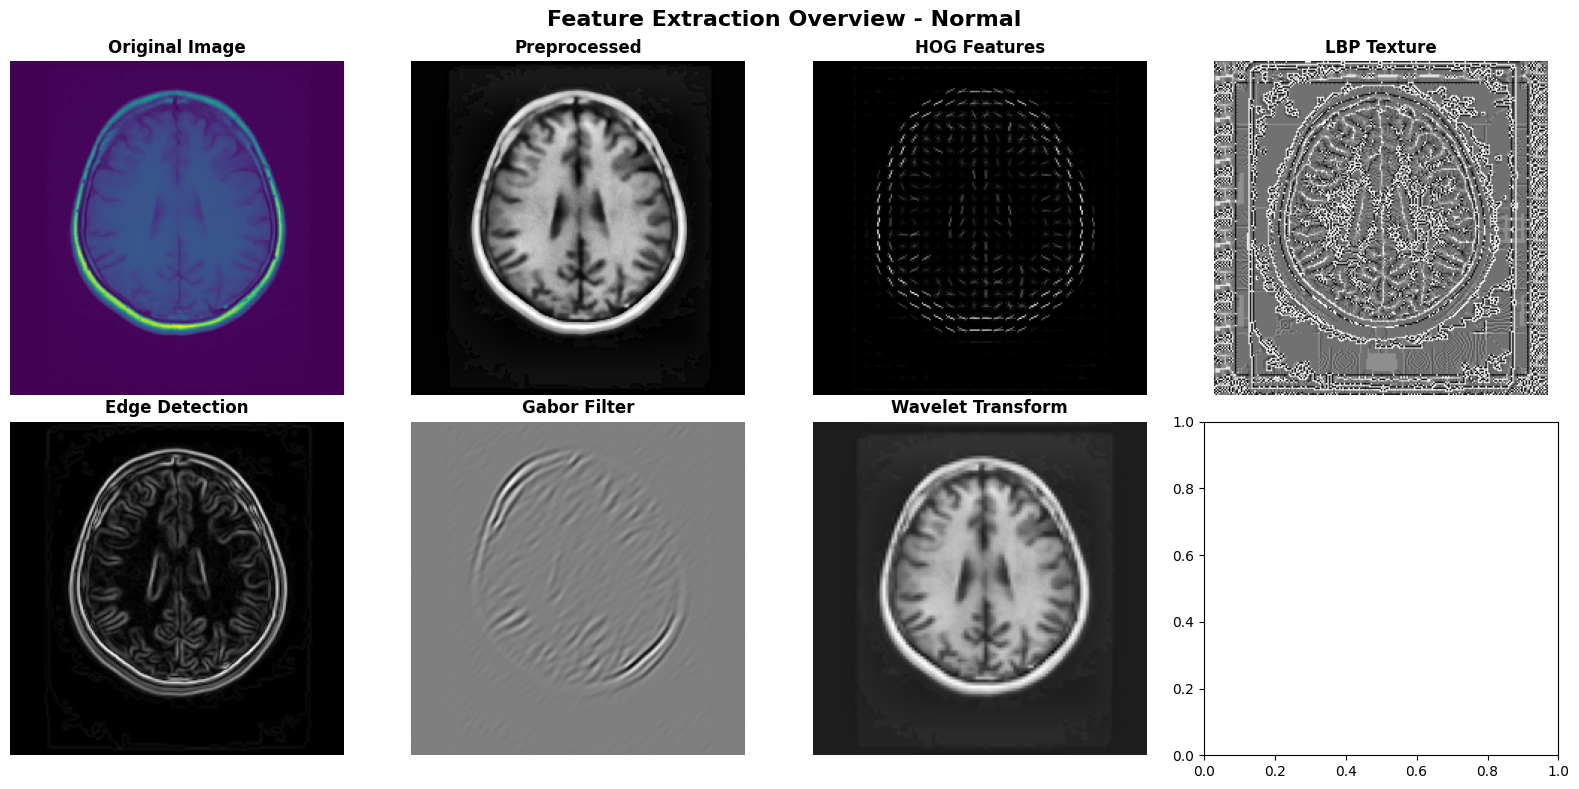


   Showing features for Tumor...


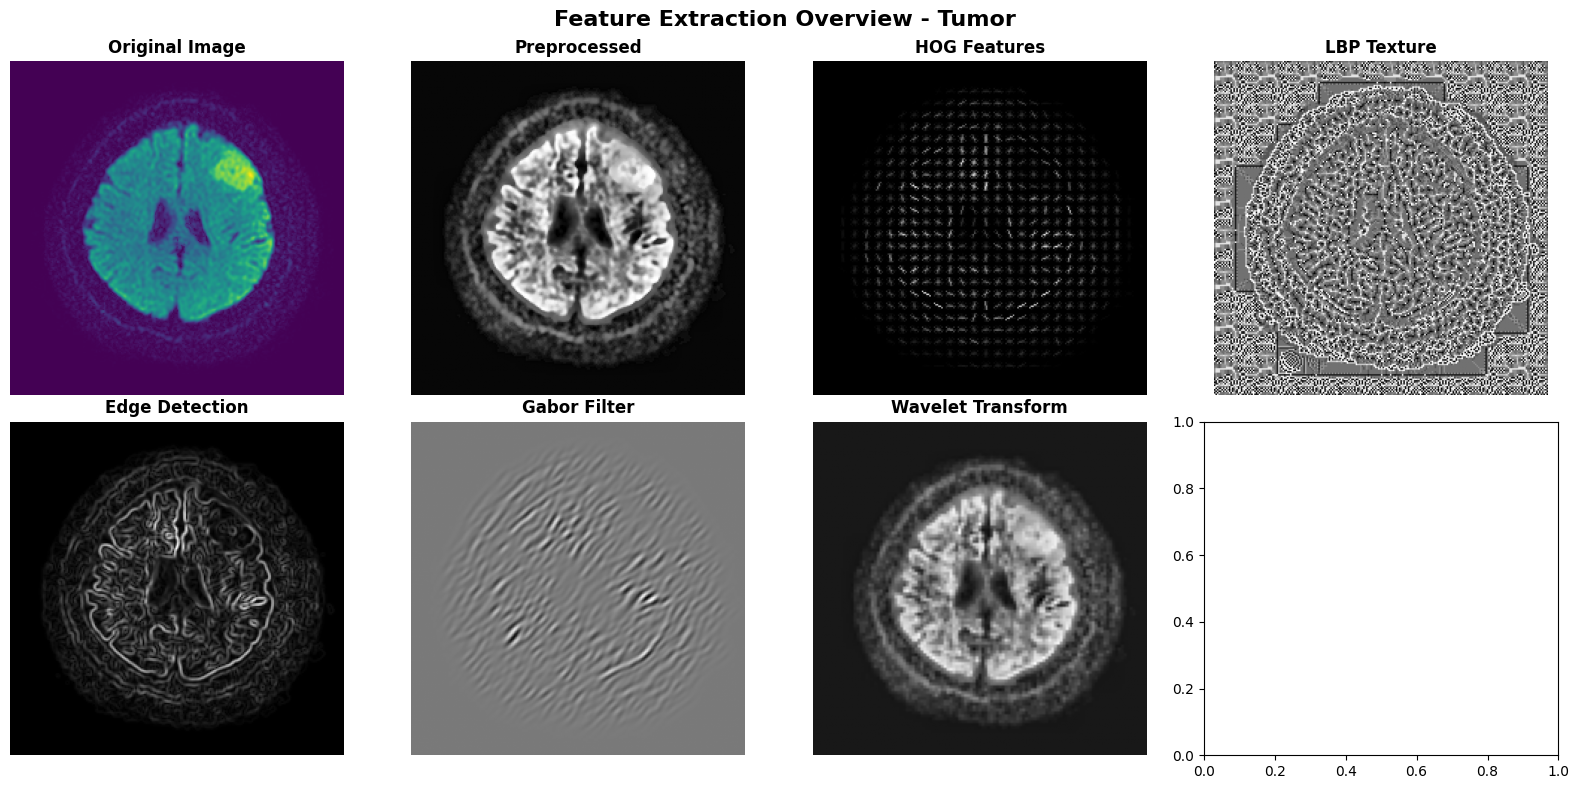


2. Generating Final Class Classifications...


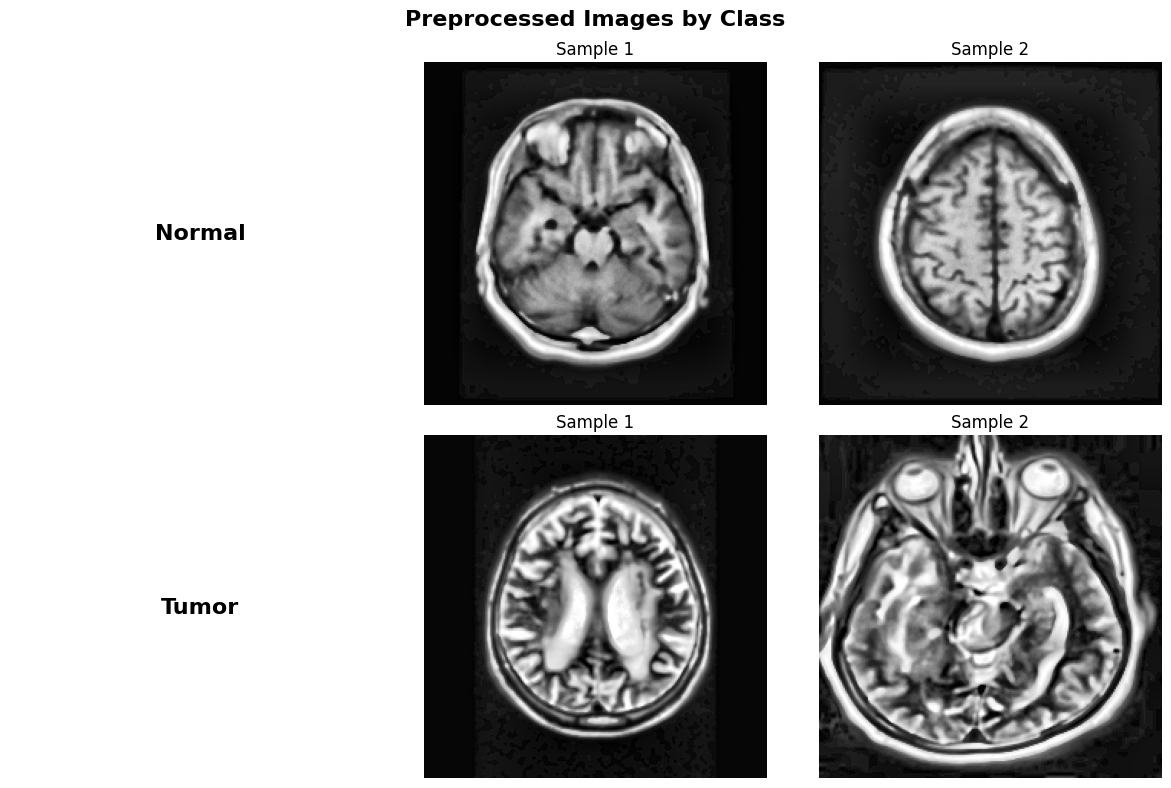


FINAL EXTRACTION SUMMARY

Dataset Size: 6999 Valid Images
Detected Classes: Normal, Tumor

Class Distribution Match:
  Normal: 3799 images (54.3%)
  Tumor: 3200 images (45.7%)

Engineered Features: 26386 individual metrics per image
Global Machine Learning Matrix Definition (X_data format): (6999, 26386)
Final RAM Cost footprint: 1409.0 MB


✓ Verification Complete. Matrix ready for ML Splitting!


In [6]:
# ==========================================
# FEATURE EXTRACTION VISUALIZATION SUITE
# ==========================================

def visualize_feature_extraction(image_idx, images, preprocessed_images, labels, class_folders):
    """
    Plots a multi-grid visual breakdown of what the mathematical feature extractors 
    are actually "seeing" when looking at a brain scan.
    Parameters:
    -----------
    image_idx : int
        Index of the specific image array to audit.
    images : list
        List of raw, original images.
    preprocessed_images : list
        List of normalized, [0,1] preprocessed images.
    labels : list
        List of integer class labels.
    class_folders : list
        List of string class names (used for titling).
    """
    
    original = images[image_idx]
    preprocessed = preprocessed_images[image_idx]
    class_name = class_folders[labels[image_idx]]

    # Initialize a 2-Row, 4-Column Grid
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))

    # --- ROW 1: Raw & Texture Filters ---
    
    # 1. Original Image
    axes[0, 0].imshow(original)
    axes[0, 0].set_title("Original Image", fontsize=12, weight='bold')
    axes[0, 0].axis('off')

    # 2. Preprocessed (Grayscale/CLAHE/Normalized)
    axes[0, 1].imshow(preprocessed, cmap='gray')
    axes[0, 1].set_title("Preprocessed", fontsize=12, weight='bold')
    axes[0, 1].axis('off')

    # 3. HOG (Shapes and physical structures)
    _, hog_image = feature.hog(
        preprocessed,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        visualize=True
    )
    axes[0, 2].imshow(hog_image, cmap='gray')
    axes[0, 2].set_title("HOG Features", fontsize=12, weight='bold')
    axes[0, 2].axis('off')

    # 4. LBP (Granular Micro-Textures)
    lbp = feature.local_binary_pattern(preprocessed, P=8, R=1, method='uniform')
    axes[0, 3].imshow(lbp, cmap='gray')
    axes[0, 3].set_title("LBP Texture", fontsize=12, weight='bold')
    axes[0, 3].axis('off')

    # --- ROW 2: Edges & Spectral Transforms ---
    
    # 5. Sobel Edge Detection (Finding tumor boundaries)
    from skimage import filters
    edges = filters.sobel(preprocessed)
    axes[1, 0].imshow(edges, cmap='gray')
    axes[1, 0].set_title("Edge Detection", fontsize=12, weight='bold')
    axes[1, 0].axis('off')

    # 6. Gabor Filter (Directional frequency response)
    real, _ = filters.gabor(preprocessed, frequency=0.2, theta=np.pi/4)
    axes[1, 1].imshow(real, cmap='gray')
    axes[1, 1].set_title("Gabor Filter", fontsize=12, weight='bold')
    axes[1, 1].axis('off')

    # 7. Wavelet Transform Approximation (Compression)
    import pywt
    coeffs = pywt.wavedec2(preprocessed, 'db4', level=1)
    axes[1, 2].imshow(coeffs[0], cmap='gray')
    axes[1, 2].set_title("Wavelet Transform", fontsize=12, weight='bold')
    axes[1, 2].axis('off')


    plt.suptitle(f"Feature Extraction Overview - {class_name}", fontsize=16, weight='bold')
    plt.tight_layout()
    plt.show()


def visualize_class_comparison(preprocessed_images, labels, class_folders, n_samples=2):
    """
    
    Displays a quick visual confirmation grid to compare Normal vs Tumor preprocessed images.
    """
    n_classes = len(class_folders)

    
    fig, axes = plt.subplots(n_classes, n_samples + 1, figsize=(12, 4 * n_classes))

    if n_classes == 1:
        axes = axes.reshape(1, -1)

    for class_idx, class_name in enumerate(class_folders):
        # Locate indices for current class and select random samples
        class_indices = [i for i, label in enumerate(labels) if label == class_idx]
        sample_indices = np.random.choice(class_indices, size=min(n_samples, len(class_indices)), replace=False)

        # Draw Class Row Label
        axes[class_idx, 0].text(0.5, 0.5, class_name, ha='center', va='center',
                               fontsize=16, weight='bold')
        axes[class_idx, 0].axis('off')

        # Draw Samples
        for i, idx in enumerate(sample_indices):
            axes[class_idx, i + 1].imshow(preprocessed_images[idx], cmap='gray')
            axes[class_idx, i + 1].set_title(f"Sample {i+1}")
            axes[class_idx, i + 1].axis('off')

    plt.suptitle("Preprocessed Images by Class", fontsize=16, weight='bold')
    plt.tight_layout()
    plt.show()


def create_summary_report(images, feature_matrix, labels, class_folders):
    """
    Prints a fast console breakdown of RAM Memory and Matrix Dimensions.
    """
    print("\n==========================================")
    print("FINAL EXTRACTION SUMMARY")
    print("==========================================")
    print(f"\nDataset Size: {len(images)} Valid Images")
    print(f"Detected Classes: {', '.join(class_folders)}")
    

    print("\nClass Distribution Match:")
    for class_idx, class_name in enumerate(class_folders):
        count = np.sum(labels == class_idx)
        print(f"  {class_name}: {count} images ({count/len(labels)*100:.1f}%)")

    print(f"\nEngineered Features: {feature_matrix.shape[1]} individual metrics per image")
    print(f"Global Machine Learning Matrix Definition (X_data format): {feature_matrix.shape}")
    print(f"Final RAM Cost footprint: {(feature_matrix.nbytes / 1024 / 1024):.1f} MB")
    print("==========================================\n")



# ==========================================
# MAIN EXECUTION BLOCK (VISUALIZATIONS)
# ==========================================
def run_visualizations(images, preprocessed_images, feature_matrix, labels, class_folders):
    """
    Run the simplified visualization suite.
    """
    print("\n=== Feature Extraction Visualizations ===\n")

    # 1. Show advanced mathematical breakdown for 1 image per class
    print("1. Feature extraction examples:")
    for class_idx, class_name in enumerate(class_folders):
        class_indices = [i for i, label in enumerate(labels) if label == class_idx]
        if class_indices:
            sample_idx = np.random.choice(class_indices)
            print(f"\n   Showing features for {class_name}...")
            visualize_feature_extraction(sample_idx, images, preprocessed_images,
                                       labels, class_folders)

    # 2. Show basic Normal vs Tumor comparisons
    print("\n2. Generating Final Class Classifications...")
    visualize_class_comparison(preprocessed_images, labels, class_folders)

    # 3. Print final Data Science summary
    create_summary_report(images, feature_matrix, labels, class_folders)
    print("\n✓ Verification Complete. Matrix ready for ML Splitting!")



if __name__ == "__main__":
    # Failsafe: Ensures features were actually extracted before plotting
    if 'feature_matrix' not in globals():
        print("Extracting features first...")
        feature_matrix, labels_array = extract_features_batch(
            preprocessed_images, labels, verbose=True
        )
    run_visualizations(images, preprocessed_images, feature_matrix,
                                 labels_array, class_folders)

---
## 6. Dimensionality Reduction (PCA) & Train/Test Splitting
Feeding raw features into a traditional Machine Learning model can cause the **"Curse of Dimensionality"** (where the model memorizes noise instead of learning patterns, leading to severe overfitting).

To prevent this, we perform three robust data preparation steps:
1. **Standard Scaling:** Normalizes all features to have a mean of 0 and a standard deviation of 1 (a strict requirement before PCA).
2. **Principal Component Analysis (PCA):** A mathematical algorithm that compresses the features count down into a smaller set of "Principal Components" while retaining exactly `95%` of the original mathematical variance.
3. **Stratified Data Splitting:** Safely isolates `25%` of the compressed data into a Test Set that the model has never seen, ensuring a perfectly balanced distribution of Normal/Tumor scans across both Train and Test sets.


FEATURE PREPARATION PIPELINE

1. STANDARD SCALING
  ✓ Features scaled mathematically (Mean: -0.0000, Std: 1.0000)

2. PCA COMPRESSION
  ✓ PCA compressed '26386' raw features down to just '3435' components.
  ✓ Total Mathematical Variance Retained: 94.88%

3. STRATIFIED TRAIN/TEST SPLIT
  ✓ Splitting Complete -> Training: 5249 images | Testing: 1750 images.



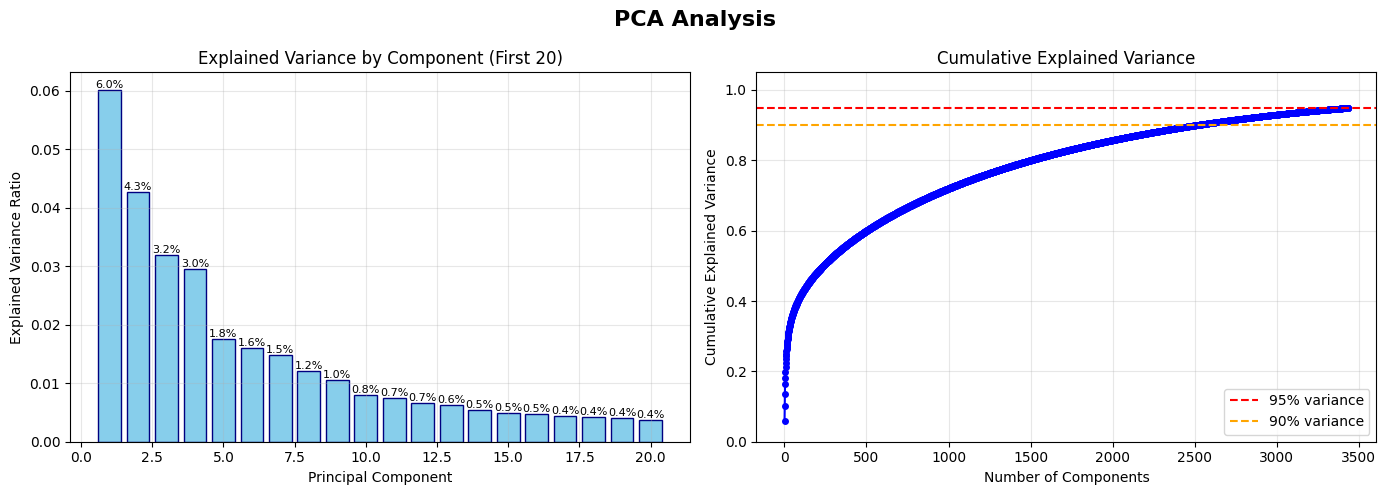

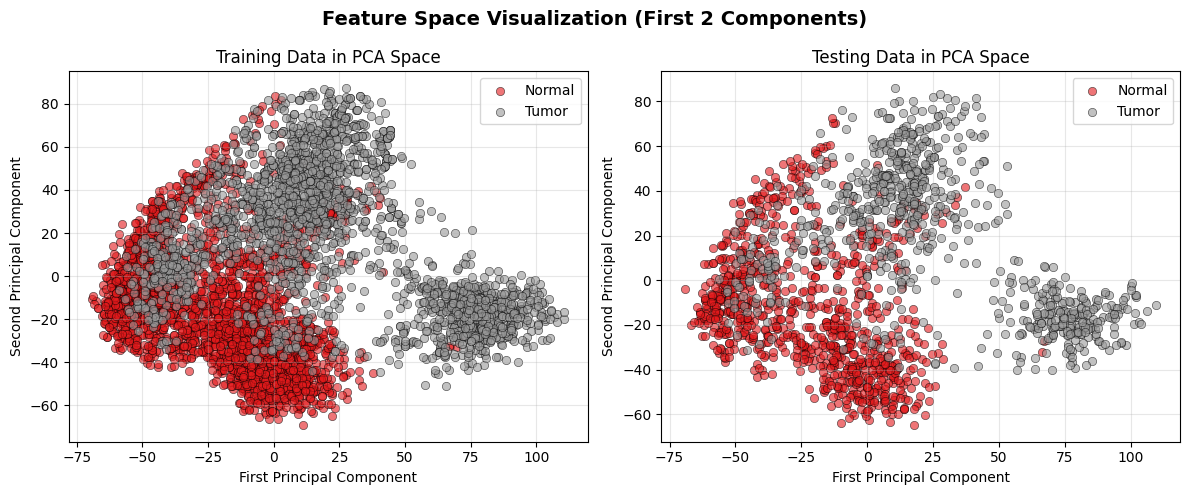

In [7]:
def prepare_features_for_modeling(feature_matrix, labels, test_size=0.25,
                                 pca_variance=0.95, random_state=42):
    """
    Prepares the raw feature matrix for Machine Learning.
    Parameters:
    -----------
    feature_matrix : numpy.ndarray
        The massive 2D array of extracted features shape: (n_images, 3928)
    labels : numpy.ndarray
        Target classifications mapping to the images (n_images,)
    test_size : float
        Percentage of data to lock away for validation/testing (Default=0.25)
    pca_variance : float
        The physical amount of original 'knowledge' (variance) PCA must retain (Default=0.95 or 95%)
    random_state : int
        Fixed seed to ensure the train/test split is exactly reproducible every time (Default=42)
    Returns:
    --------
    dict : Contains the finalized X/y datasets, the Scaler, and the PCA objects.
    """
    print("==========================================")
    print("FEATURE PREPARATION PIPELINE")
    print("==========================================")

    
    if feature_matrix.shape[0] != len(labels):
        raise ValueError("Number of samples in features and labels must match")

    # ---------------------------------------------------------
    # 1. Feature Scaling (Crucial for PCA)
    # ---------------------------------------------------------
    print("\n1. STANDARD SCALING")
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(feature_matrix)
    
    print(f"  ✓ Features scaled mathematically (Mean: {scaled_features.mean():.4f}, Std: {scaled_features.std():.4f})")

    # ---------------------------------------------------------
    # 2. Dimensionality Reduction (PCA)
    # ---------------------------------------------------------
    print("\n2. PCA COMPRESSION")
    # Fit empty PCA to calculate the variance limits
    pca_full = PCA()
    pca_full.fit(scaled_features)

    # Interrogate the PCA to find exactly how many components are needed to hit the 95% variance target
    cumsum_var = np.cumsum(pca_full.explained_variance_ratio_)
    n_components = np.argmax(cumsum_var >= pca_variance) + 1

    # Re-run PCA compressing down to only that strict number of components
    pca = PCA(n_components=n_components)
    pca_features = pca.fit_transform(scaled_features)

    print(f"  ✓ PCA compressed '{scaled_features.shape[1]}' raw features down to just '{pca_features.shape[1]}' components.")
    print(f"  ✓ Total Mathematical Variance Retained: {pca.explained_variance_ratio_.sum():.2%}")

    # ---------------------------------------------------------
    # 3. Train / Test Split
    # ---------------------------------------------------------
    print("\n3. STRATIFIED TRAIN/TEST SPLIT")
    # 'Stratify=labels' forces the split to maintain the exact ratio of Normal/Tumor images in both sets

    X_train, X_test, y_train, y_test = train_test_split(
        pca_features, labels,
        test_size=test_size,
        random_state=random_state,
        stratify=labels  # Maintain class distribution
    )

    print(f"  ✓ Splitting Complete -> Training: {X_train.shape[0]} images | Testing: {X_test.shape[0]} images.")


    feature_info = {
        'original_features': feature_matrix.shape[1],
        'pca_features': pca_features.shape[1],
        'variance_retained': pca.explained_variance_ratio_.sum(),
        'n_training_samples': X_train.shape[0],
        'n_testing_samples': X_test.shape[0]
    }

    print("==========================================\n")

    return {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'scaler': scaler,
        'pca': pca,
        'feature_info': feature_info
    }


def visualize_pca_analysis(pca, n_components_show=20):
    """Generates analytical charts tracking PCA compression and variance limits."""

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # --- Plot 1: Individual Variance per Component ---
    n_components = len(pca.explained_variance_ratio_)
    components_to_show = min(n_components, n_components_show)

    ax1.bar(range(1, components_to_show + 1),
            pca.explained_variance_ratio_[:components_to_show],
            color='skyblue', edgecolor='navy')
    ax1.set_xlabel('Principal Component')
    ax1.set_ylabel('Explained Variance Ratio')
    ax1.set_title(f'Explained Variance by Component (First {components_to_show})')
    ax1.grid(True, alpha=0.3)

    for i, var in enumerate(pca.explained_variance_ratio_[:components_to_show]):
        ax1.text(i + 1, var, f'{var:.1%}', ha='center', va='bottom', fontsize=8)

    # --- Plot 2: Cumulative Total Variance ---
    cumsum_var = np.cumsum(pca.explained_variance_ratio_)
    ax2.plot(range(1, n_components + 1), cumsum_var, 'bo-', markersize=4)
    ax2.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
    ax2.axhline(y=0.90, color='orange', linestyle='--', label='90% variance')
    ax2.set_xlabel('Number of Components')
    ax2.set_ylabel('Cumulative Explained Variance')
    ax2.set_title('Cumulative Explained Variance')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    ax2.set_ylim([0, 1.05])

    plt.suptitle('PCA Analysis', fontsize=16, weight='bold')
    plt.tight_layout()
    plt.show()


def plot_feature_space_2d(X_train, X_test, y_train, y_test, class_names):
    """
    Maps out the physical overlap between Normal and Tumor data points strictly across 
    the first two mathematical Principal Components.
    """
    plt.figure(figsize=(12, 5))

    # Display Train Data
    plt.subplot(1, 2, 1)
    colors = plt.cm.Set1(np.linspace(0, 1, len(class_names)))

    for idx, (class_name, color) in enumerate(zip(class_names, colors)):
        mask = y_train == idx
        plt.scatter(X_train[mask, 0], X_train[mask, 1],
                   c=[color], label=class_name, alpha=0.6, edgecolors='black', linewidth=0.5)

    plt.xlabel('First Principal Component')
    plt.ylabel('Second Principal Component')
    plt.title('Training Data in PCA Space')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Display Testing Data
    plt.subplot(1, 2, 2)
    for idx, (class_name, color) in enumerate(zip(class_names, colors)):
        mask = y_test == idx
        plt.scatter(X_test[mask, 0], X_test[mask, 1],
                   c=[color], label=class_name, alpha=0.6, edgecolors='black', linewidth=0.5)

    plt.xlabel('First Principal Component')
    plt.ylabel('Second Principal Component')
    plt.title('Testing Data in PCA Space')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.suptitle('Feature Space Visualization (First 2 Components)', fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()



# ==========================================
# MAIN EXECUTION BLOCK (SPLITTING & SCALING)
# ==========================================
if __name__ == "__main__":
    # Execute exactly 25% stratification split while retaining 95% mathematical variance
    prep_results = prepare_features_for_modeling(
        feature_matrix,
        labels_array,
        test_size=0.25,
        pca_variance=0.95,  # Retain 95% of variance
        random_state=42
    )

    # Unpack the highly compressed, standardized final Data matrices
    X_train = prep_results['X_train']
    X_test = prep_results['X_test']
    y_train = prep_results['y_train']
    y_test = prep_results['y_test']
    scaler = prep_results['scaler']
    pca = prep_results['pca']

    # Produce Analytical Audits
    visualize_pca_analysis(pca)

    # Visualize feature space (if PCA reduced to at least 2 components)
    if X_train.shape[1] >= 2:
        plot_feature_space_2d(X_train, X_test, y_train, y_test, class_folders)



---
## 7. Model Training & Automated Evaluation (The ML Bake-Off)
With our data clean, compressed, and strictly separated, it is time to build the actual Artificial Intelligence.
Because Classical Machine Learning algorithms each have different mathematical philosophies, we don't just rely on one. Instead, we instantiate a **Dictionary of 5 distinct algorithms** and force them to compete:
1. **Random Forest:** An ensemble of hundreds of decision trees voting together.
2. **K-Nearest Neighbors (KNN):** Classifies based on physical proximity in the PCA space.
3. **Support Vector Machine (SVC):** Draws strict mathematical borders (hyperplanes) between classes.
4. **Decision Tree:** A pure, logical flowchart algorithm.
5. **Naive Bayes:** Probabilistic classification based on Bayes' Theorem.
Each model is subjected to strict **5-Fold Cross Validation** (to prove it isn't just getting lucky) and timed. Finally, the script mathematically scores and selects the definitive "Champion" model for Brain Tumor classification!

Initializing Machine Learning Bake-Off...


TRAINING INITIATED: Random Forest

Performing 5-fold cross-validation...
  --> Fold Scores: [0.90761905 0.90190476 0.92095238 0.88666667 0.8970448 ]
  --> Mean Stable Accuracy: 0.9028 (+/- 0.0227)

Training on full training set...

Final Training Set Accuracy: 1.0000
Final Blind Testing Accuracy: 0.9229
Compute Time: 45.77 seconds

Classification Report:
              precision    recall  f1-score   support

      Normal       0.89      0.98      0.93       950
       Tumor       0.97      0.86      0.91       800

    accuracy                           0.92      1750
   macro avg       0.93      0.92      0.92      1750
weighted avg       0.93      0.92      0.92      1750



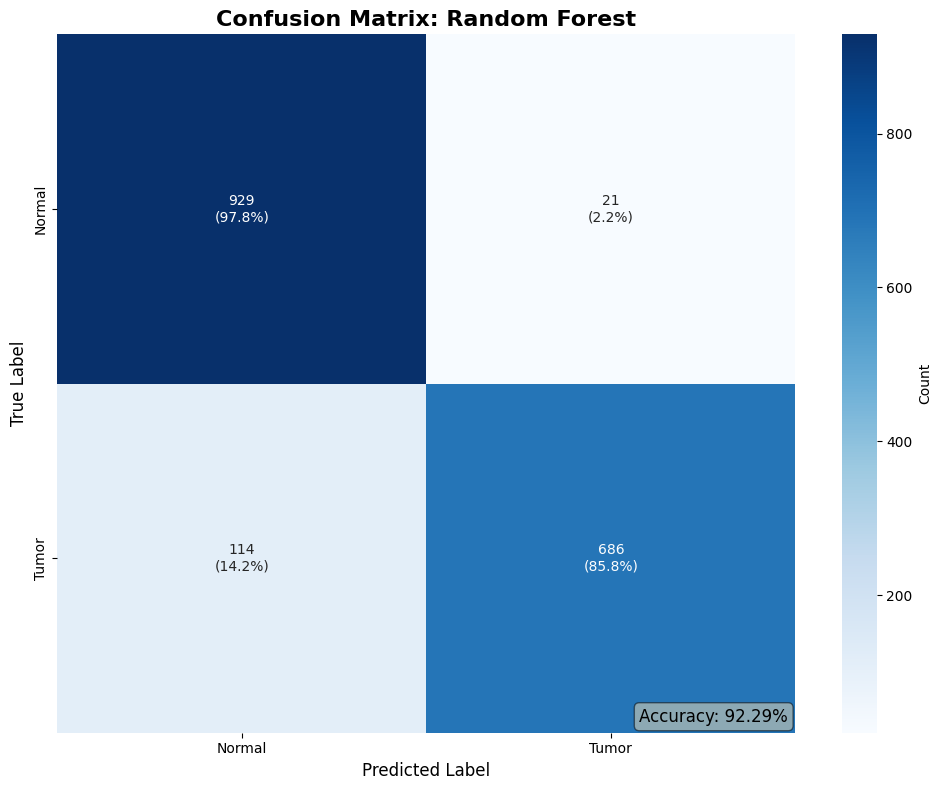


TRAINING INITIATED: K-Nearest Neighbors

Performing 5-fold cross-validation...
  --> Fold Scores: [0.96285714 0.95904762 0.9647619  0.95714286 0.96282173]
  --> Mean Stable Accuracy: 0.9613 (+/- 0.0056)

Training on full training set...

Final Training Set Accuracy: 1.0000
Final Blind Testing Accuracy: 0.9691
Compute Time: 13.55 seconds

Classification Report:
              precision    recall  f1-score   support

      Normal       0.95      1.00      0.97       950
       Tumor       1.00      0.93      0.97       800

    accuracy                           0.97      1750
   macro avg       0.97      0.97      0.97      1750
weighted avg       0.97      0.97      0.97      1750



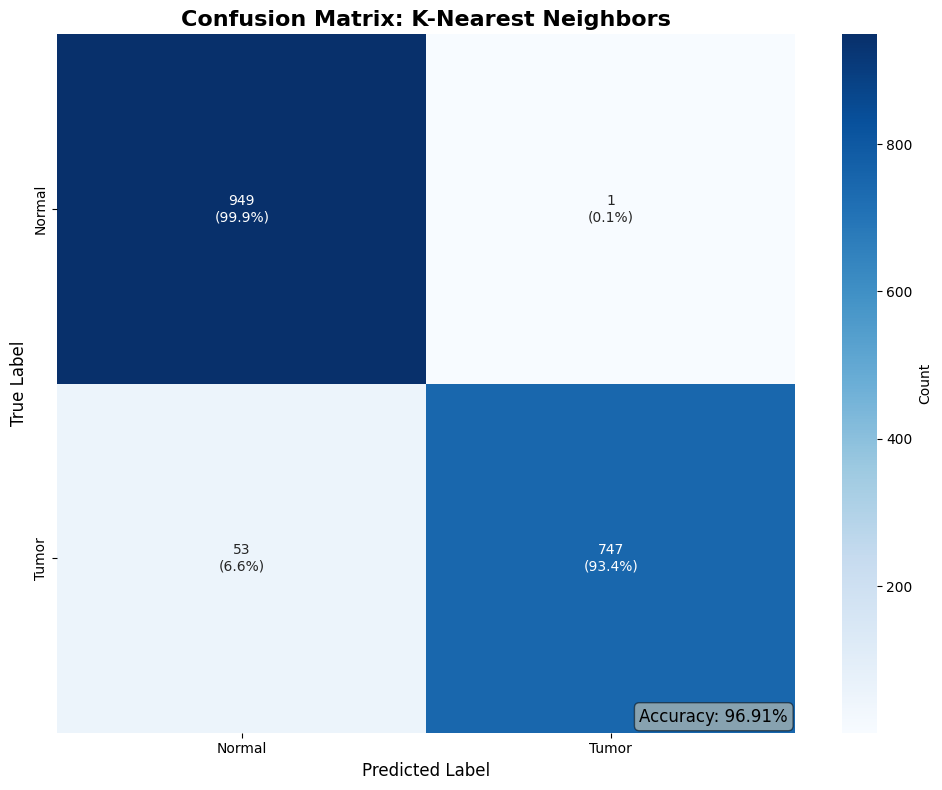


TRAINING INITIATED: Support Vector Machine

Performing 5-fold cross-validation...
  --> Fold Scores: [0.9752381  0.96095238 0.97714286 0.9752381  0.97235462]
  --> Mean Stable Accuracy: 0.9722 (+/- 0.0116)

Training on full training set...

Final Training Set Accuracy: 0.9981
Final Blind Testing Accuracy: 0.9823
Compute Time: 467.86 seconds

Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      1.00      0.98       950
       Tumor       0.99      0.97      0.98       800

    accuracy                           0.98      1750
   macro avg       0.98      0.98      0.98      1750
weighted avg       0.98      0.98      0.98      1750



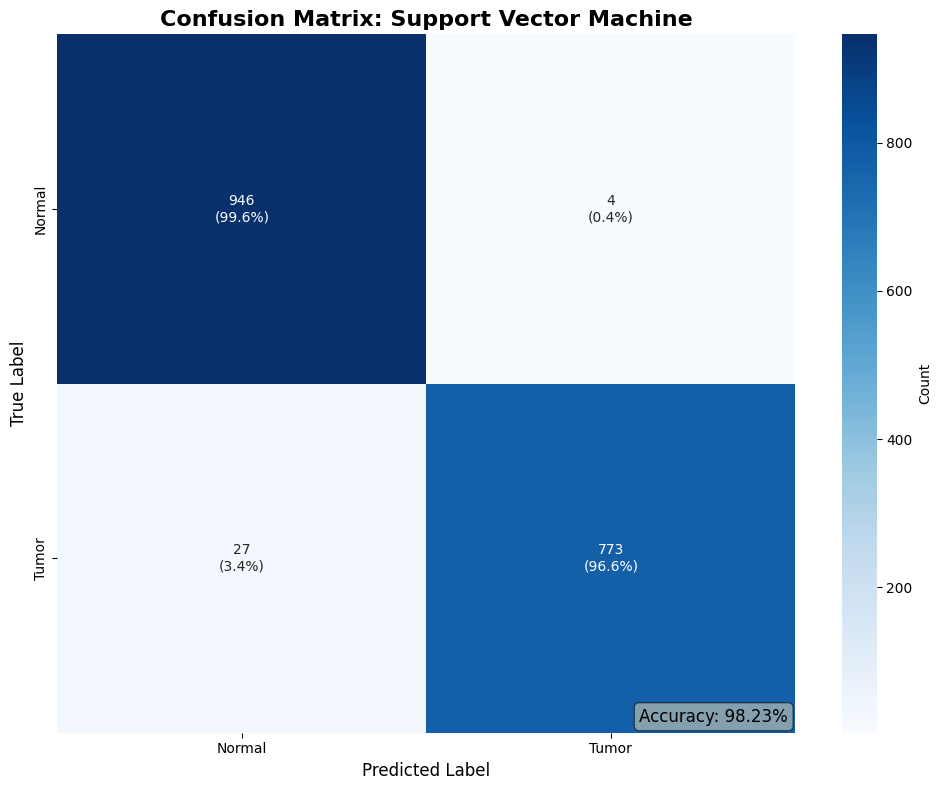


TRAINING INITIATED: Decision Tree

Performing 5-fold cross-validation...
  --> Fold Scores: [0.88857143 0.84761905 0.87238095 0.87904762 0.86749285]
  --> Mean Stable Accuracy: 0.8710 (+/- 0.0273)

Training on full training set...

Final Training Set Accuracy: 1.0000
Final Blind Testing Accuracy: 0.8846
Compute Time: 70.29 seconds

Classification Report:
              precision    recall  f1-score   support

      Normal       0.91      0.87      0.89       950
       Tumor       0.86      0.90      0.88       800

    accuracy                           0.88      1750
   macro avg       0.88      0.89      0.88      1750
weighted avg       0.89      0.88      0.88      1750



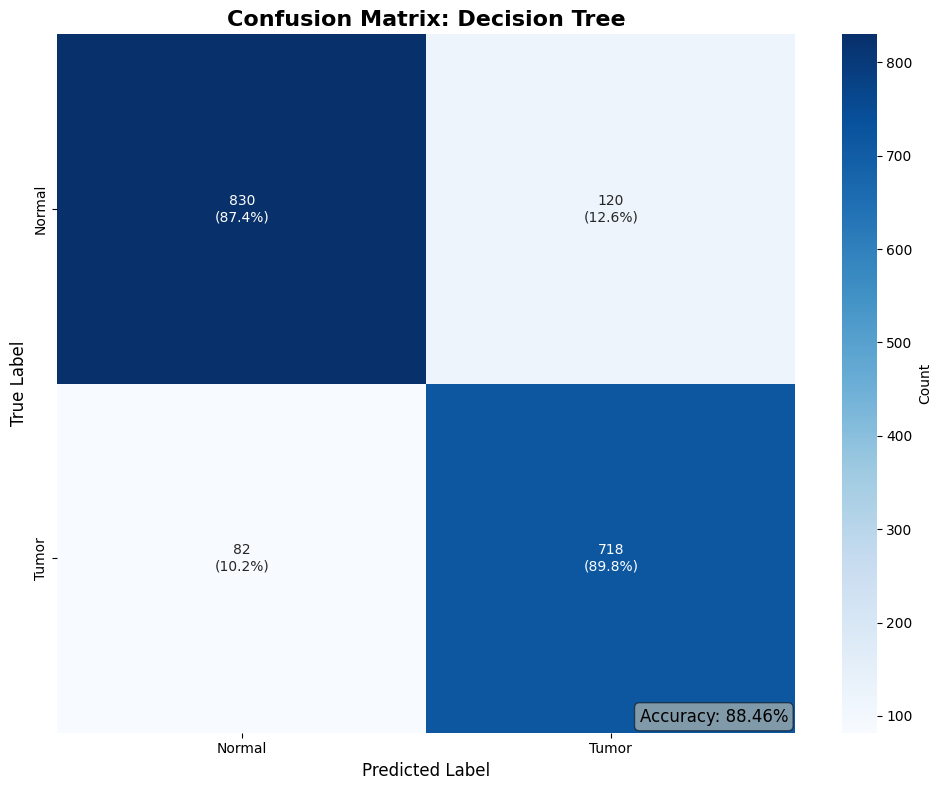


TRAINING INITIATED: Naive Bayes

Performing 5-fold cross-validation...
  --> Fold Scores: [0.6647619  0.66285714 0.6752381  0.64095238 0.67206864]
  --> Mean Stable Accuracy: 0.6632 (+/- 0.0240)

Training on full training set...

Final Training Set Accuracy: 0.6950
Final Blind Testing Accuracy: 0.6646
Compute Time: 5.96 seconds

Classification Report:
              precision    recall  f1-score   support

      Normal       0.67      0.76      0.71       950
       Tumor       0.66      0.55      0.60       800

    accuracy                           0.66      1750
   macro avg       0.66      0.66      0.66      1750
weighted avg       0.66      0.66      0.66      1750



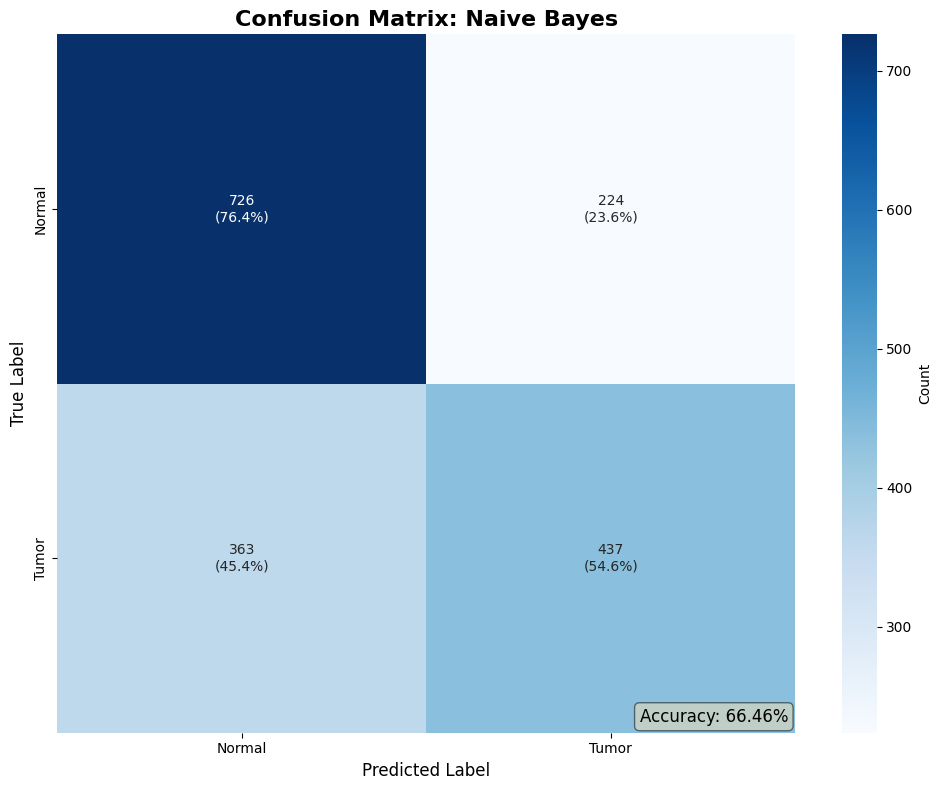


ALGORITHM BAKE-OFF COMPARISON


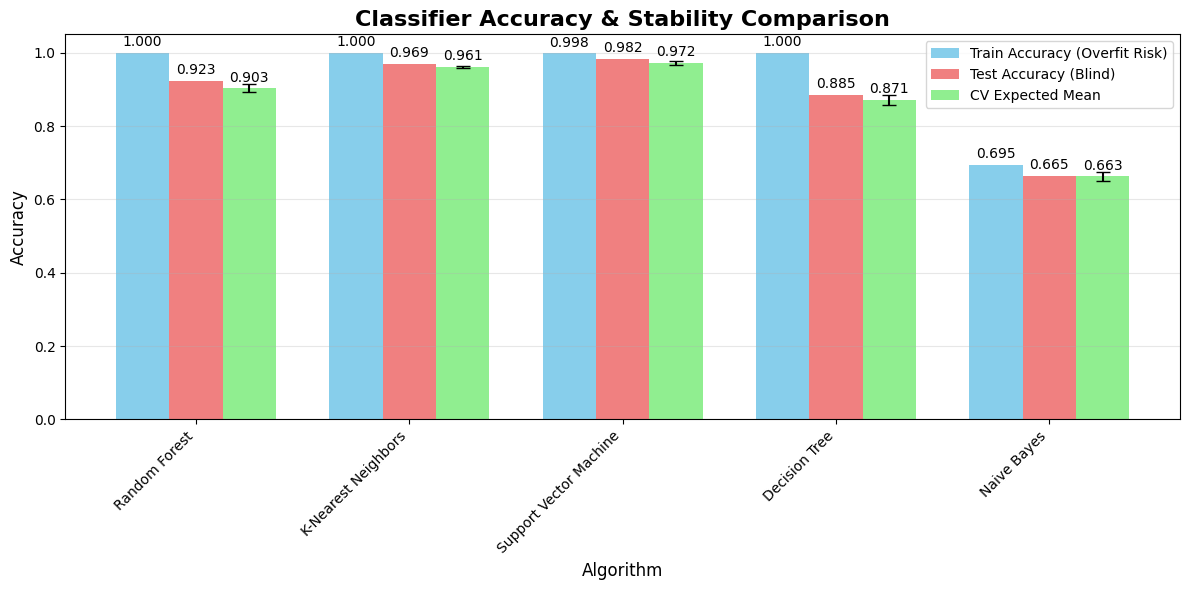

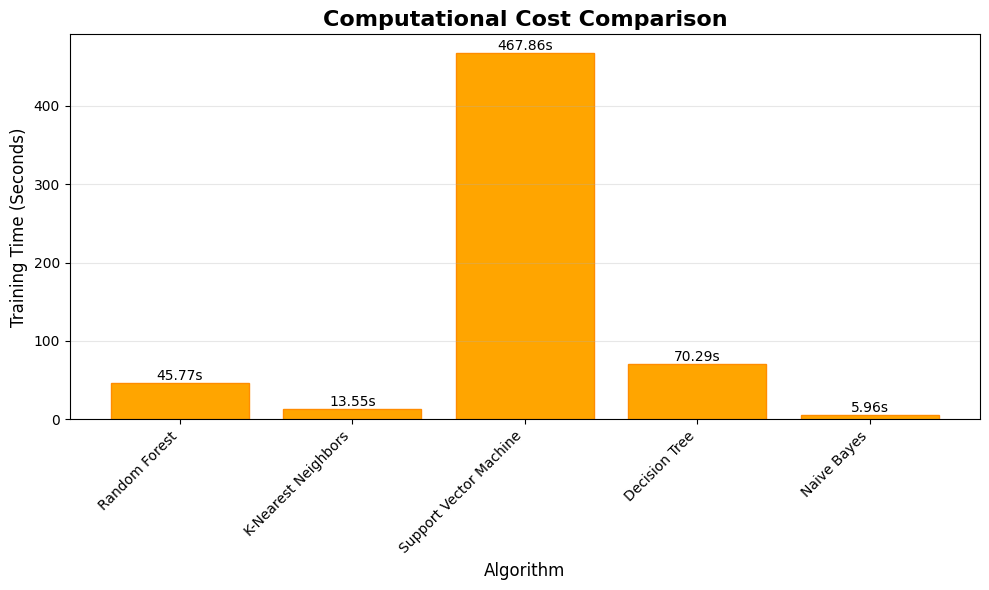

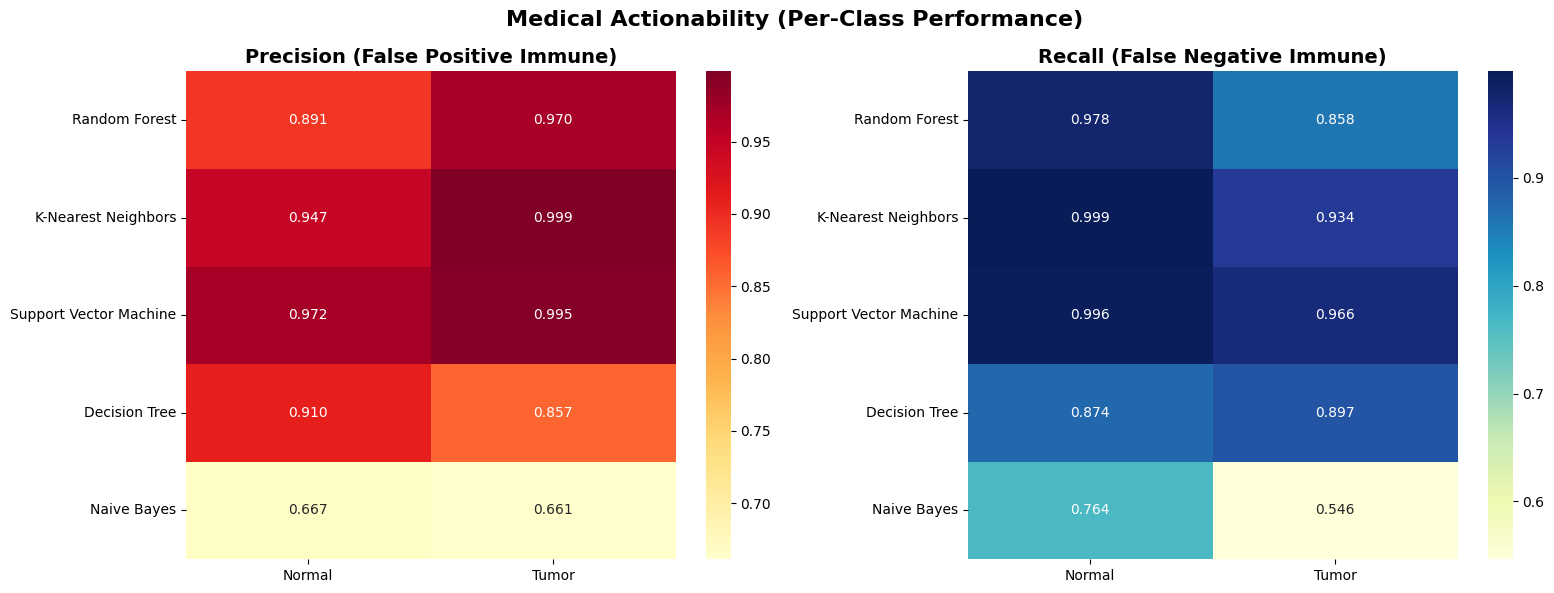


CHAMPION CLASSIFIER SELECTION
  K-Nearest Neighbors Total Score: 0.96894
  Random Forest Total Score: 0.91979
  Support Vector Machine Total Score: 0.88365
  Decision Tree Total Score: 0.88041
  Naive Bayes Total Score: 0.71202

 CHAMPION DECLARED: K-Nearest Neighbors 

✓ Bake-Off Complete! The Champion is: K-Nearest Neighbors
  Winning Blind Test Accuracy: 0.9691


In [8]:
# ==========================================
# MACHINE LEARNING PIPELINE & EVALUATION
# ==========================================
def create_classifiers():
    """
    Instantiates an arsenal of Machine Learning algorithms with pre-optimized hyperparameters.
    Returns:
    --------
    dict : A dictionary mapping the string name of the algorithm to its Scikit-Learn object.
    """
    classifiers = {
        'Random Forest': RandomForestClassifier(
            n_estimators=100,
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            random_state=42,
            n_jobs=-1
        ),
        'K-Nearest Neighbors': KNeighborsClassifier(
            n_neighbors=5,
            weights='distance',
            metric='minkowski',
            p=2,
            n_jobs=-1 # Utilize all CPU cores for faster training
        ),
        'Support Vector Machine': SVC(
            kernel='rbf',
            C=1.0,
            gamma='scale',
            probability=True,
            random_state=42
        ),
        'Decision Tree': DecisionTreeClassifier(
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            random_state=42
        ),
        'Naive Bayes': GaussianNB()
    }

    return classifiers


def train_and_evaluate_classifier(clf, X_train, X_test, y_train, y_test,
                                 class_names, classifier_name, cv_folds=5):
    """
    Subjects a single classifier to rigorous testing, including Cross-Validation and Confusion Matrix plotting.
    
    Returns:
    --------
    dict : A comprehensive payload containing the trained model, accuracies, timings, and classifications.
    """
    print(f"\n{'='*60}")
    print(f"TRAINING INITIATED: {classifier_name}")
    print('='*60)

    start_time = time.time()

    # 1. Rigorous Audit: K-Fold Cross Validation
    print(f"\nPerforming {cv_folds}-fold cross-validation...")
    cv_scores = cross_val_score(clf, X_train, y_train, cv=cv_folds,
                               scoring='accuracy', n_jobs=-1)

    print(f"  --> Fold Scores: {cv_scores}")
    print(f"  --> Mean Stable Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

    # 2. Main Training Phase
    print("\nTraining on full training set...")
    clf.fit(X_train, y_train)

    # 3. Blind Prediction (Testing)
    y_pred = clf.predict(X_test)
    y_pred_proba = clf.predict_proba(X_test) if hasattr(clf, 'predict_proba') else None

    # Calculate raw metrics
    accuracy = accuracy_score(y_test, y_pred)
    train_accuracy = clf.score(X_train, y_train)
    training_time = time.time() - start_time

    print(f"\nFinal Training Set Accuracy: {train_accuracy:.4f}")
    print(f"Final Blind Testing Accuracy: {accuracy:.4f}")
    print(f"Compute Time: {training_time:.2f} seconds")

    # Print Scikit-Learn Classification Breakdown
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=class_names))

    # Package results into payload dictionary
    return {
        'classifier': clf,
        'accuracy': accuracy,
        'train_accuracy': train_accuracy,
        'predictions': y_pred,
        'probabilities': y_pred_proba,
        'confusion_matrix': confusion_matrix(y_test, y_pred),
        'cv_scores': cv_scores,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'training_time': training_time,
        'classification_report': classification_report(y_test, y_pred, target_names=class_names, output_dict=True)
    }


def visualize_confusion_matrix(cm, class_names, title):
    """Renders a Heatmap matrix showing exactly where the model got confused (False Positives/Negatives)."""
    plt.figure(figsize=(10, 8))

    # Calculate exact percentages for display
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    annotations = np.empty_like(cm).astype(str)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annotations[i, j] = f'{cm[i, j]}\n({cm_percent[i, j]:.1f}%)'

    sns.heatmap(cm, annot=annotations, fmt='', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'})

    plt.title(title, fontsize=16, weight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)

    accuracy = np.trace(cm) / np.sum(cm)
    plt.text(0.99, 0.01, f'Accuracy: {accuracy:.2%}',
             transform=plt.gca().transAxes,
             ha='right', va='bottom', fontsize=12,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.show()


def compare_classifiers(results, class_names):
    """Renders visual bar charts to pit all algorithms against each other based on Accuracy, CPU Time, and Precision."""
    
    names = list(results.keys())
    test_acc = [results[name]['accuracy'] for name in names]
    train_acc = [results[name]['train_accuracy'] for name in names]
    cv_means = [results[name]['cv_mean'] for name in names]
    cv_stds = [results[name]['cv_std'] for name in names]
    times = [results[n]['training_time'] for n in names]

    # --- 1. Accuracy vs Overfitting Comparison ---
    plt.figure(figsize=(12, 6))
    x = np.arange(len(names))
    width = 0.25
    plt.bar(x - width, train_acc, width, label='Train Accuracy (Overfit Risk)', color='skyblue')
    plt.bar(x, test_acc, width, label='Test Accuracy (Blind)', color='lightcoral')
    plt.bar(x + width, cv_means, width, yerr=cv_stds, label='CV Expected Mean', color='lightgreen', capsize=5)
    plt.xlabel('Algorithm', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.title('Classifier Accuracy & Stability Comparison', fontsize=16, weight='bold')
    plt.xticks(x, names, rotation=45, ha='right')
    plt.legend()
    plt.grid(True, alpha=0.3, axis='y')
    plt.ylim([0, 1.05])
    for i, (train, test, cv) in enumerate(zip(train_acc, test_acc, cv_means)):
        plt.text(i - width, train + 0.01, f'{train:.3f}', ha='center', va='bottom')
        plt.text(i, test + 0.01, f'{test:.3f}', ha='center', va='bottom')
        plt.text(i + width, cv + 0.01, f'{cv:.3f}', ha='center', va='bottom')
        
    plt.tight_layout()
    plt.show()



    # --- 2. CPU Training Time Comparison ---
    plt.figure(figsize=(10, 6))
    bars = plt.bar(names, times, color='orange', edgecolor='darkorange')
    plt.xlabel('Algorithm', fontsize=12)
    plt.ylabel('Training Time (Seconds)', fontsize=12)
    plt.title('Computational Cost Comparison', fontsize=16, weight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.3, axis='y')
    for bar, t in zip(bars, times):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{t:.2f}s', ha='center', va='bottom')
        
    plt.tight_layout()
    plt.show()

    # --- 3. Per-Class Precision & Recall Heatmaps ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    precision_matrix = [[results[n]['classification_report'][c]['precision'] for c in class_names] for n in names]
    recall_matrix = [[results[n]['classification_report'][c]['recall'] for c in class_names] for n in names]
    sns.heatmap(precision_matrix, annot=True, fmt='.3f', cmap='YlOrRd', xticklabels=class_names, yticklabels=names, ax=axes[0])
    axes[0].set_title('Precision (False Positive Immune)', fontsize=14, weight='bold')
    sns.heatmap(recall_matrix, annot=True, fmt='.3f', cmap='YlGnBu', xticklabels=class_names, yticklabels=names, ax=axes[1])
    axes[1].set_title('Recall (False Negative Immune)', fontsize=14, weight='bold')
    plt.suptitle('Medical Actionability (Per-Class Performance)', fontsize=16, weight='bold')
    plt.tight_layout()
    plt.show()


def select_best_classifier(results):
    """
    Automated Judge: Scores each model based on a weighted penalty system.
    Weights: Blind Accuracy (80%), Stability/CV (5%), Overfitting gap (5%), and Speed (10%).
    """
    
    scores = {}
    max_time = max(results[name]['training_time'] for name in results)

    for name, result in results.items():
        # Formula penalizes slow models, models that overfit, and models with low blind accuracy
        time_score = 1 - (result['training_time'] / max_time)
        train_test_gap = abs(result['train_accuracy'] - result['accuracy'])

        weighted_score = (result['accuracy'] * 0.80) + (result['cv_mean'] * 0.05) + ((1 - train_test_gap) * 0.05) + (time_score * 0.10)
        scores[name] = weighted_score

    best_classifier = max(scores, key=scores.get)

    print("\n" + "="*60)
    print("CHAMPION CLASSIFIER SELECTION")
    print("="*60)
    for name, score in sorted(scores.items(), key=lambda x: x[1], reverse=True):
        print(f"  {name} Total Score: {score:.5f}")
    
    print(f"\n CHAMPION DECLARED: {best_classifier} ")
    print("="*60)
    return best_classifier


# Main execution
def run_classifier_comparison(X_train, X_test, y_train, y_test, class_names):
    """Main Orchestrator function to execute the Machine Learning Bake-Off."""
    
    classifiers = create_classifiers()
    results = {}

    # Cycle through the Dictionary of algorithms and test them one by one
    for name, clf in classifiers.items():
        results[name] = train_and_evaluate_classifier(clf, X_train, X_test, y_train, y_test, class_names, name, cv_folds=5)
        visualize_confusion_matrix(results[name]['confusion_matrix'], class_names, f'Confusion Matrix: {name}')
    print("\n" + "="*60)
    print("ALGORITHM BAKE-OFF COMPARISON")
    print("="*60)
    compare_classifiers(results, class_names)
    
    best_classifier = select_best_classifier(results)
    return results, best_classifier



# ==========================================
# MAIN EXECUTION BLOCK (MODEL TRAINING)
# ==========================================
if __name__ == "__main__":
    print("Initializing Machine Learning Bake-Off...\n")
    results, best_classifier = run_classifier_comparison(
        X_train, X_test, y_train, y_test, class_folders
    )
    print(f"\n✓ Bake-Off Complete! The Champion is: {best_classifier}")
    print(f"  Winning Blind Test Accuracy: {results[best_classifier]['accuracy']:.4f}")